In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("tsf_compare/data/weather/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
df.shape

(420551, 15)

In [27]:
df.drop(columns=['No', 'cbwd', 'Is', 'Ir'], inplace=True)
df.head()

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws
0,2010,1,1,0,NaN,-21,-11.0,1021.0,1.79
1,2010,1,1,1,NaN,-21,-12.0,1020.0,4.92
2,2010,1,1,2,NaN,-21,-11.0,1019.0,6.71
3,2010,1,1,3,NaN,-21,-14.0,1019.0,9.84
4,2010,1,1,4,NaN,-20,-12.0,1018.0,12.97


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    43824 non-null  int64  
 1   month   43824 non-null  int64  
 2   day     43824 non-null  int64  
 3   hour    43824 non-null  int64  
 4   pm2.5   41757 non-null  float64
 5   DEWP    43824 non-null  int64  
 6   TEMP    43824 non-null  float64
 7   PRES    43824 non-null  float64
 8   Iws     43824 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 3.0 MB


In [29]:
df.shape, df.dtypes

((43824, 9),
 year       int64
 month      int64
 day        int64
 hour       int64
 pm2.5    float64
 DEWP       int64
 TEMP     float64
 PRES     float64
 Iws      float64
 dtype: object)

In [30]:
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

df_grouped = df.groupby(df["datetime"].dt.date).mean(numeric_only=True)
df_grouped.head()

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws
datetime,,,,,,,,,
2010-01-01,2010.0,1.0,1.0,11.5,NaN,-18.750000,-6.750000,1017.083333,14.458333
2010-01-02,2010.0,1.0,2.0,11.5,145.958333,-8.500000,-5.125000,1024.750000,24.860000
2010-01-03,2010.0,1.0,3.0,11.5,78.833333,-10.125000,-8.541667,1022.791667,70.937917
2010-01-04,2010.0,1.0,4.0,11.5,31.333333,-20.875000,-11.500000,1029.291667,111.160833
2010-01-05,2010.0,1.0,5.0,11.5,42.458333,-24.583333,-14.458333,1033.625000,56.920000


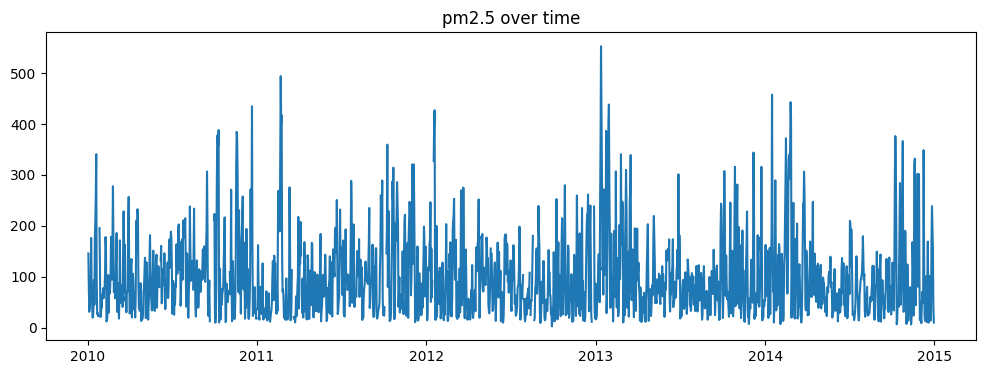

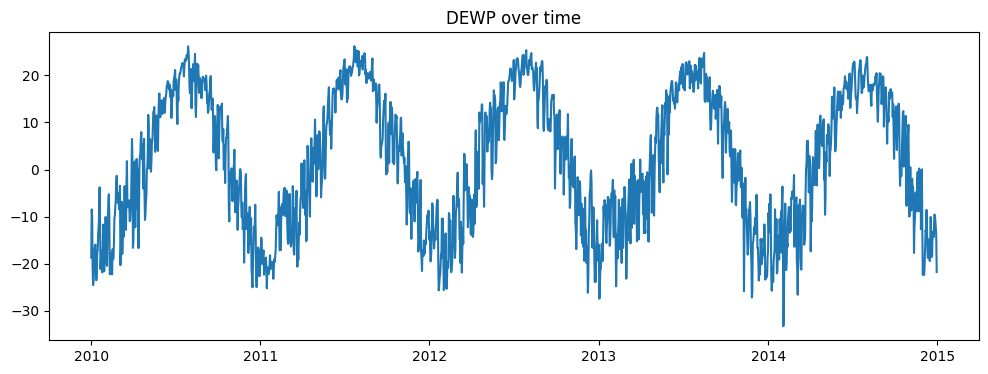

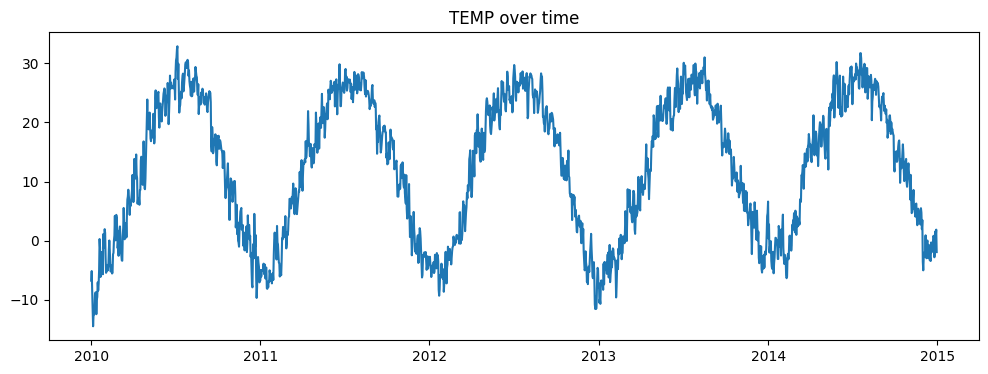

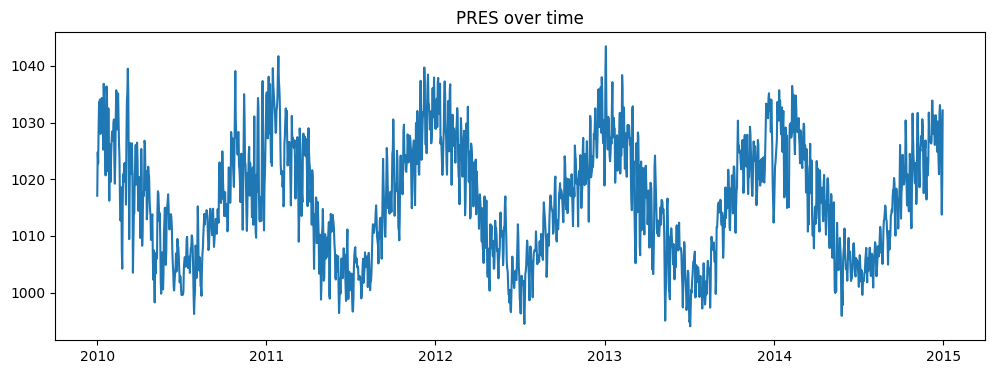

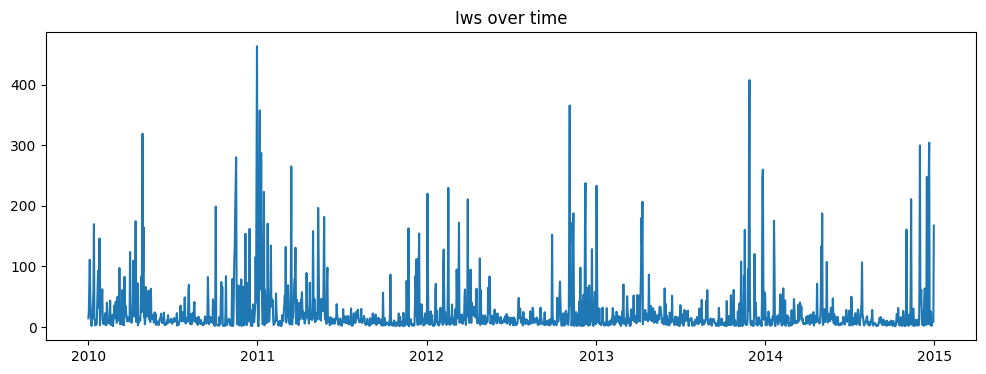

In [31]:
for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
    plt.figure(figsize=(12, 4))
    plt.plot(df_grouped[col][:10000])
    plt.title(f"{col} over time")

In [32]:
df_grouped.shape

(1826, 9)

In [33]:
1826/365

5.002739726027397

### Only using data of 25 days

In [34]:
df = df_grouped[:5*365]
df_raw = df.copy()
df.head()

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws
datetime,,,,,,,,,
2010-01-01,2010.0,1.0,1.0,11.5,NaN,-18.750000,-6.750000,1017.083333,14.458333
2010-01-02,2010.0,1.0,2.0,11.5,145.958333,-8.500000,-5.125000,1024.750000,24.860000
2010-01-03,2010.0,1.0,3.0,11.5,78.833333,-10.125000,-8.541667,1022.791667,70.937917
2010-01-04,2010.0,1.0,4.0,11.5,31.333333,-20.875000,-11.500000,1029.291667,111.160833
2010-01-05,2010.0,1.0,5.0,11.5,42.458333,-24.583333,-14.458333,1033.625000,56.920000


### Smoothing using rolling mean

/tmp/ipykernel_233029/1549145145.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()


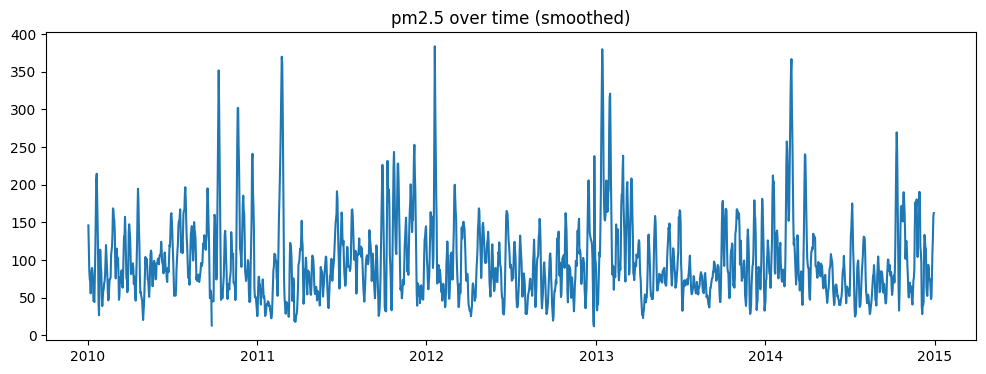

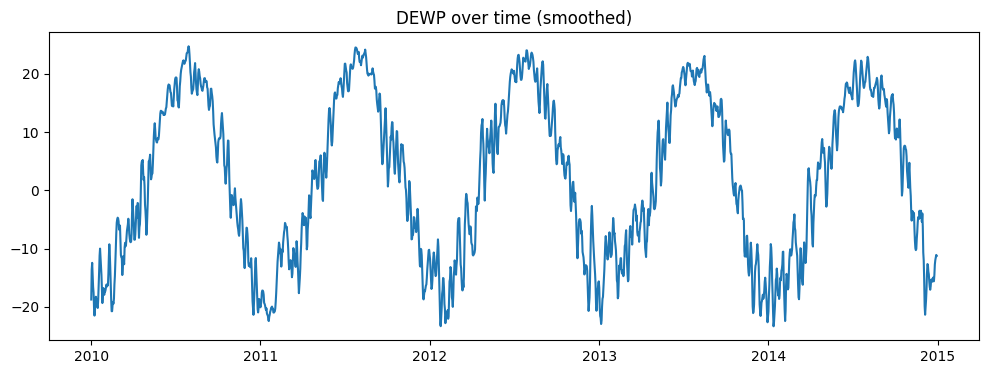

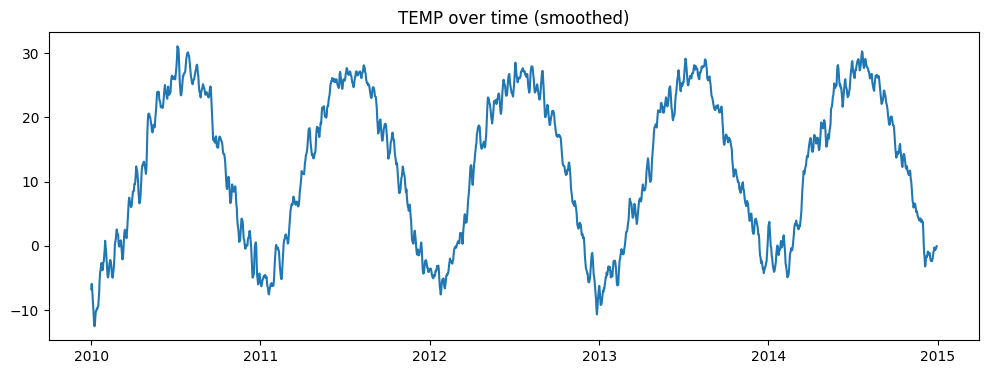

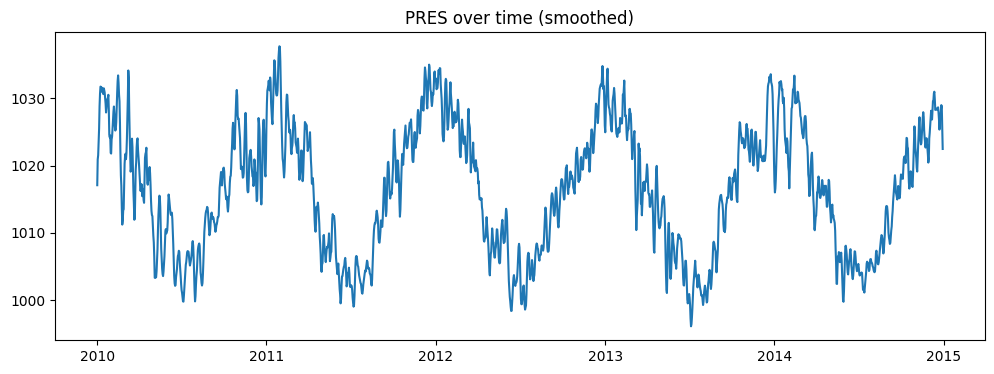

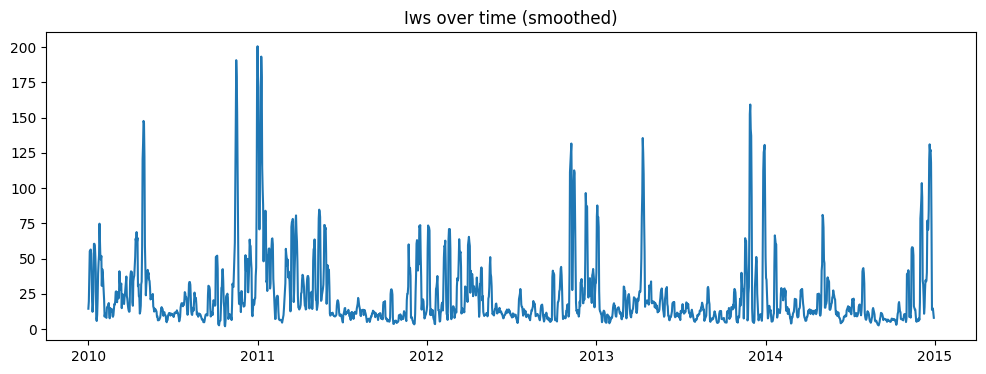

In [35]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
    plt.figure(figsize=(12, 4))
    plt.plot(df[col][:10000])
    plt.title(f"{col} over time (smoothed)")

In [36]:
TOTAL_POINTS = len(df)
PERIOD = 5
TRAIN_DAYS = 4
TEST_DAYS = 1
TIME = TOTAL_POINTS // PERIOD
FEATURES = 4
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 5 x 365 x 4


In [37]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(5, 365, 4)

In [38]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (4, 365, 4)
Test tensor shape: (1, 365, 4)


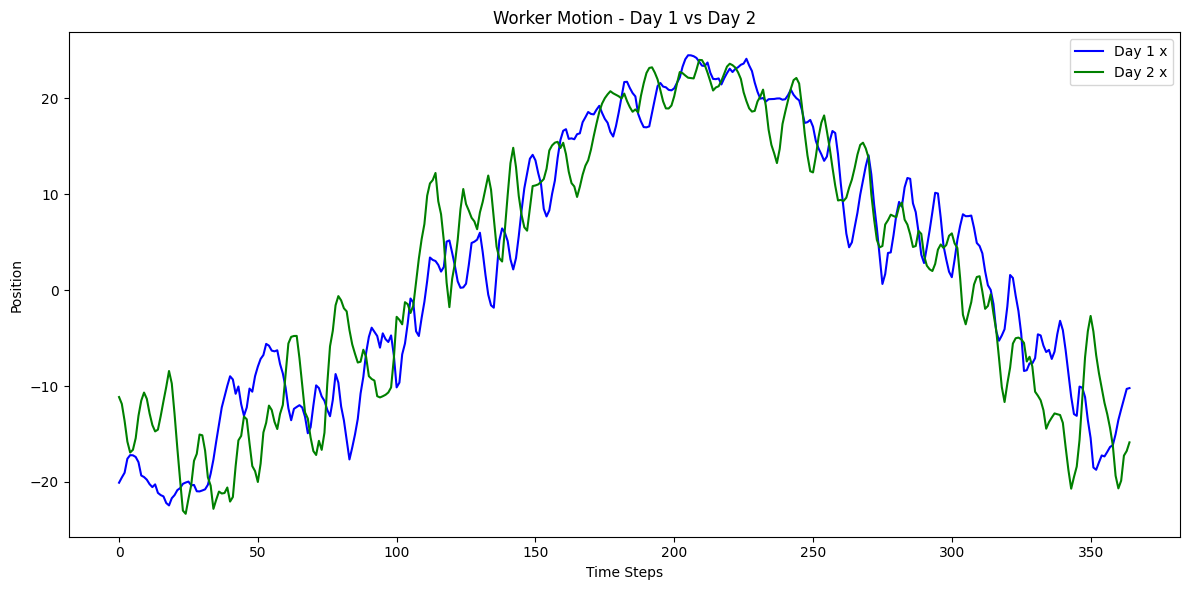

In [39]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [40]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (4, 2)
Time factors shape: (365, 2)
Feature factors shape: (4, 2)


In [41]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (4, 365, 4)
Reconstructed tensor shape: (4, 365, 4)


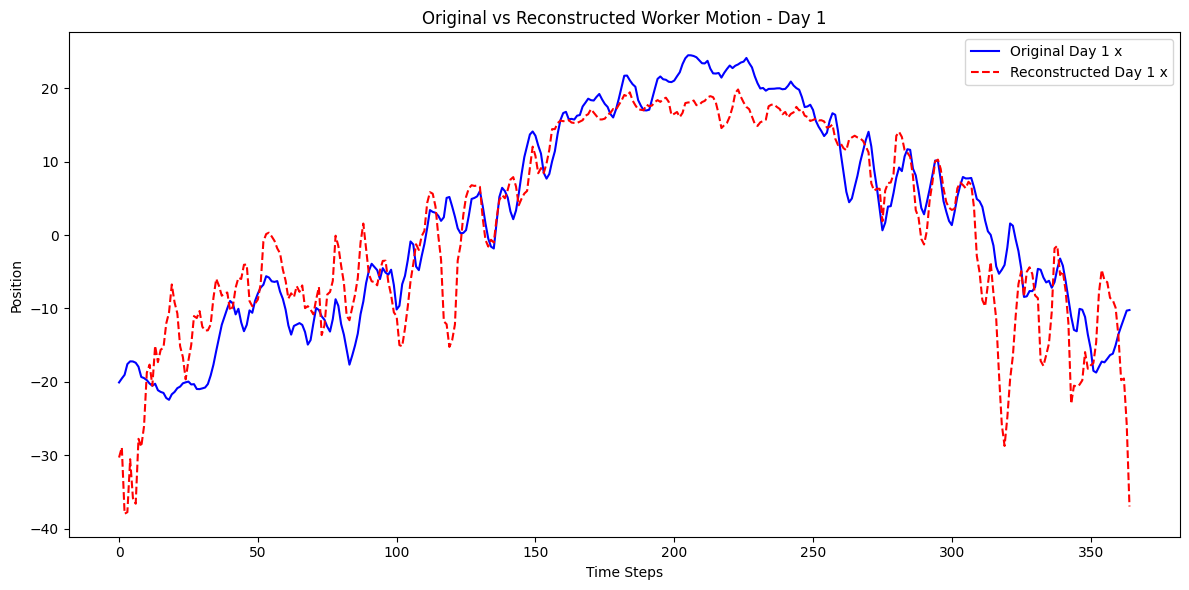

In [42]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [43]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

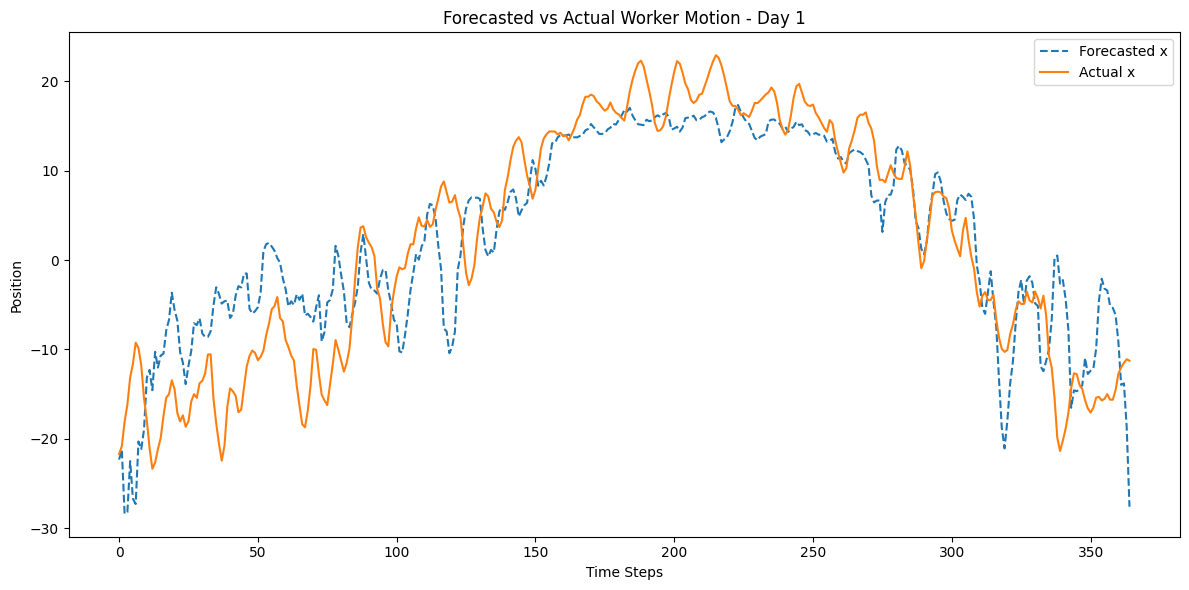

In [44]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

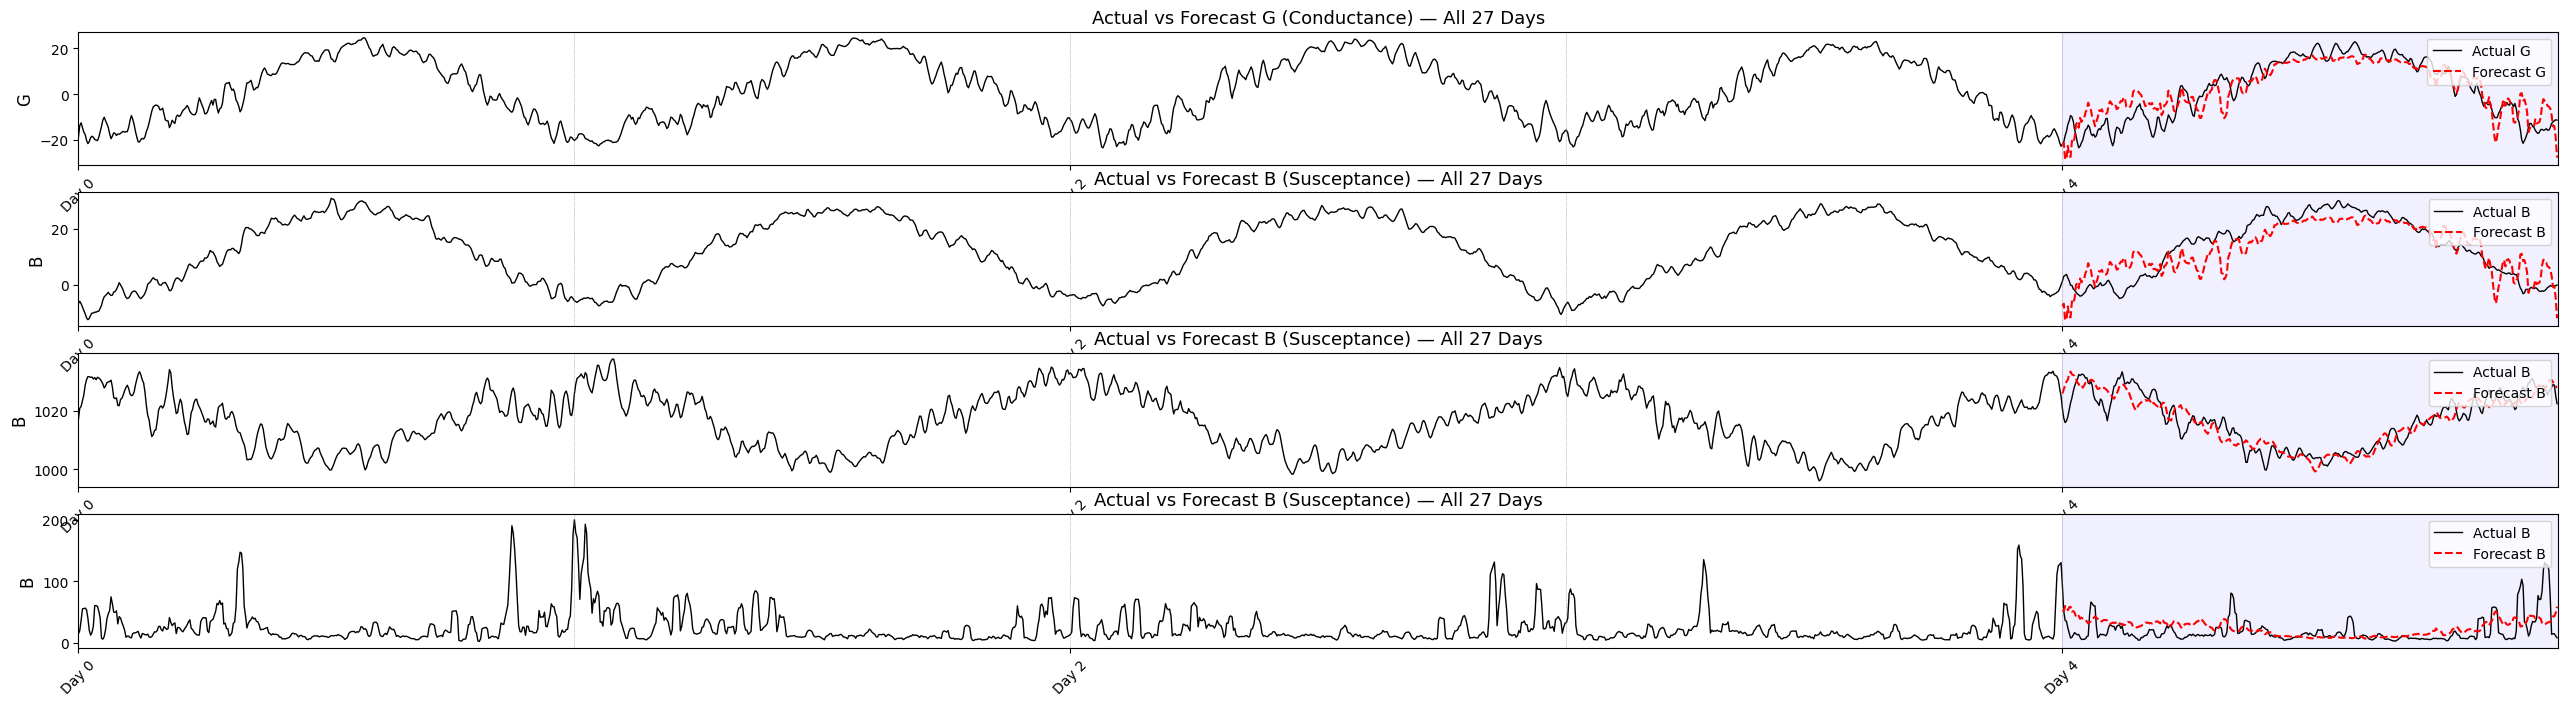

In [45]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(32, 8))

plt.subplot(4, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

Test series shape: (365, 4)
Forecast series shape: (365, 4)
x shape: (365,)


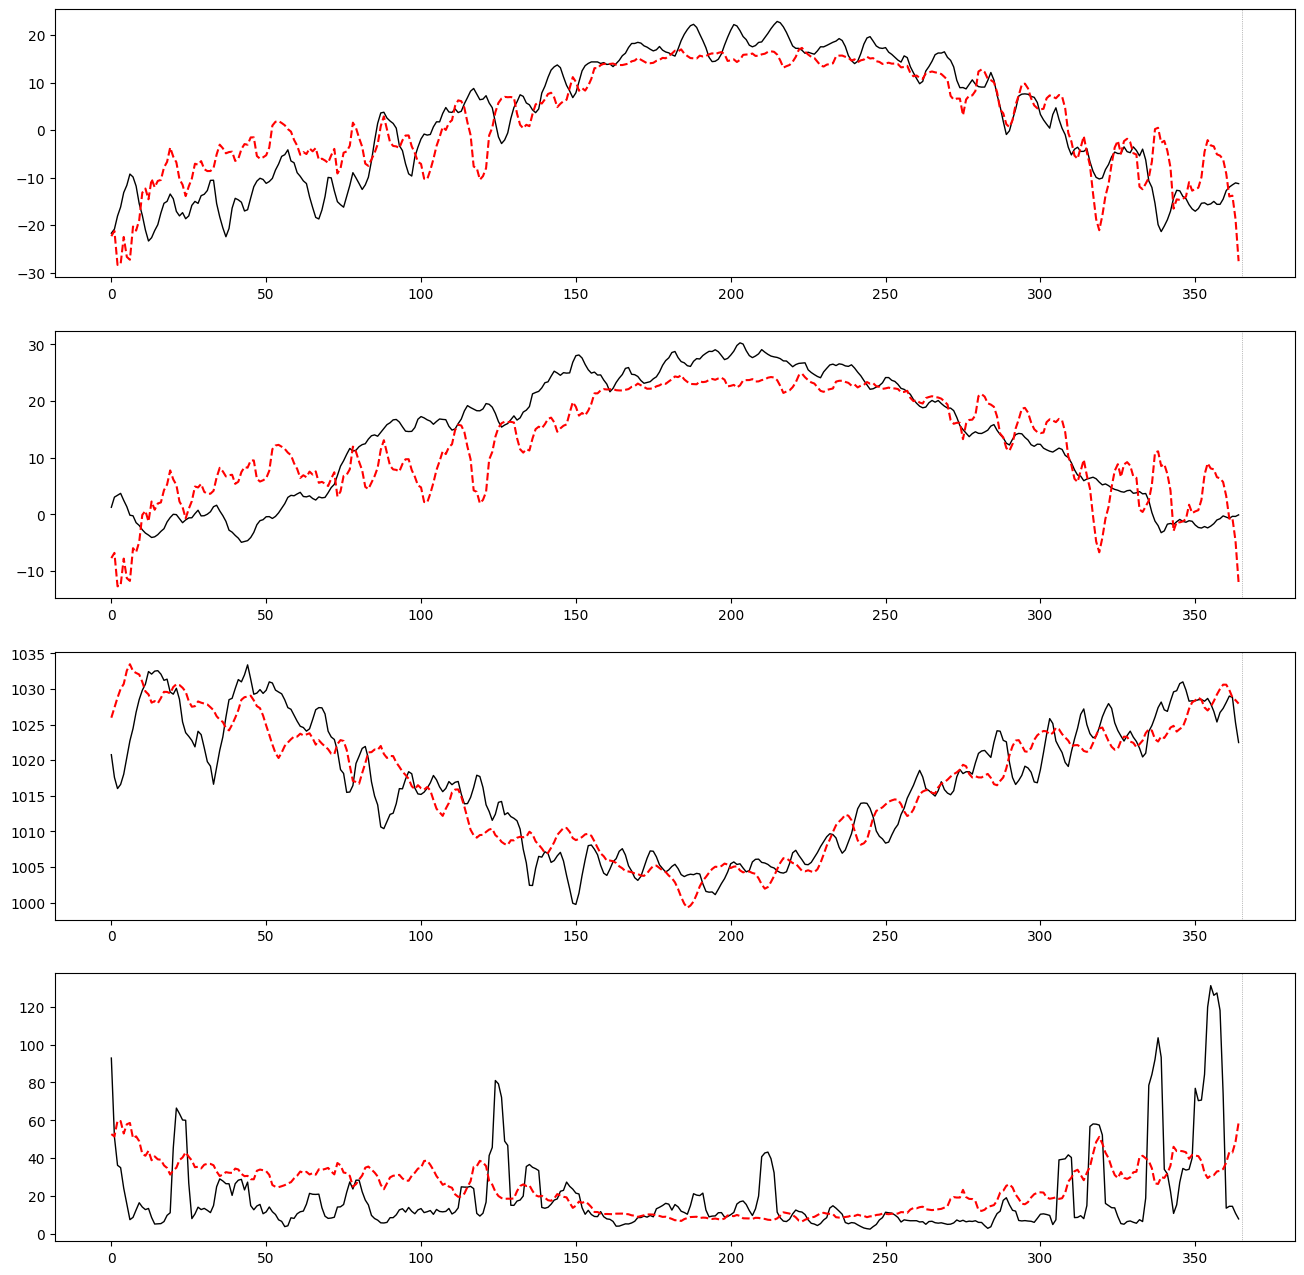

In [46]:
# Flatten full tensor and forecast tensor into time series
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)
plt.figure(figsize=(16, 16))

print(f"Test series shape: {test_series.shape}")
print(f"Forecast series shape: {forecast_series.shape}")
print(f"x shape: {x.shape}")

plt.subplot(4, 1, 1)
plt.plot(test_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 2)
plt.plot(test_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 3)
plt.plot(test_series[:, 2], 'k-', lw=1, label='Actual C')
plt.plot(forecast_series[:, 2], 'r--', lw=1.5, label='Forecast C')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    
plt.subplot(4, 1, 4)
plt.plot(test_series[:, 3], 'k-', lw=1, label='Actual D')
plt.plot(forecast_series[:, 3], 'r--', lw=1.5, label='Forecast D')
for d in range(1, TEST_DAYS + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)


In [47]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((1460, 4), (365, 4))

In [48]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

r2_a = r2_score(test_series[:, 0], forecast_series[:, 0])
r2_b = r2_score(test_series[:, 1], forecast_series[:, 1])
r2_c = r2_score(test_series[:, 2], forecast_series[:, 2])
r2_d = r2_score(test_series[:, 3], forecast_series[:, 3])
# r2_e = r2_score(test_series[:, 4], forecast_series[:, 4])
# r2_f = r2_score(test_series[:, 5], forecast_series[:, 5])
# r2_g = r2_score(test_series[:, 6], forecast_series[:, 6])

r2_scores = {
    'Col 1': r2_a,
    'Col 2': r2_b,
    'Col 3': r2_c,
    'Col 4': r2_d,
    # 'Col 5': r2_e,
    # 'Col 6': r2_f,
    # 'Col 7': r2_g
}

r2_scores_df = pd.DataFrame(list(r2_scores.items()), columns=['Column', 'R² Score'])
print(r2_scores_df)

  Column  R² Score
0  Col 1  0.761977
1  Col 2  0.682386
2  Col 3  0.798397
3  Col 4 -0.037886
